In [8]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from kmodes.kprototypes import KPrototypes
#from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import pickle


In [9]:
df = pd.read_stata("../data/HCMST Couples Meet 2017-2022 v2.2.dta", convert_categoricals=True)

/var/folders/lk/bg_vtzyj3fz74y0bzpbl63fm0000gn/T/ipykernel_51196/56858837.py:1: UnicodeWarning: 
One or more strings in the dta file could not be decoded using utf-8, and
so the fallback encoding of latin-1 is being used.  This can happen when a file
has been incorrectly encoded by Stata or some other software. You should verify
the string values returned are correct.
  df = pd.read_stata("../data/HCMST Couples Meet 2017-2022 v2.2.dta", convert_categoricals=True)


In [10]:
df

,caseid_new,w3_Weight,w3_Weight_LGB,w3_combo_weight,w3_attrition_adj_weight,w2_weight_genpop,w2_weight_LGB,w2_combo_weight,w2_attrition_adj_weights,w1_weight_combo,...,p20_pppa1634,p20_pppa1902,p20_pppa1903,p20_pppa1904,p20_ppp22001,p20_pppa1905,p20_pppa1648,p20_ppp20072,p20_ppp20071,p20_ppp2date2020
0,53001,0.4422,NaN,0.495308,0.400185,0.3856,NaN,0.437670,0.380351,0.426861,...,Female,No,Female,No,No,No,No religion,Never,NaN,20210506.0
1,71609,0.8284,NaN,0.927891,0.879258,0.9196,NaN,1.043778,0.953948,1.295508,...,Female,No,Female,No,No,No,"Evangelical or Protestant Christian (Baptist, ...",Once a year or less,Yes,20201118.0
2,106983,0.8255,NaN,0.924643,0.706467,0.7748,NaN,0.879425,0.724682,1.126573,...,Male,Male,No,No,No,No,Catholic,A few times a year,No,20210429.0
3,121759,NaN,NaN,NaN,NaN,0.9177,NaN,1.041622,0.793093,0.933440,...,Male,Male,No,No,No,No,Other Christian religion,Once a week,Yes,20210507.0
4,158083,0.8810,NaN,0.986809,0.655467,0.8697,NaN,0.987140,0.735473,0.931291,...,Male,Male,No,No,No,No,No religion,Never,NaN,20210602.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3505,2967957,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.594351,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3506,2968357,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.196247,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3507,2968971,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.383199,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3508,2969933,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.197115,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3510 entries, 0 to 3509
Columns: 725 entries, caseid_new to p20_ppp2date2020
dtypes: category(586), datetime64[s](8), float32(46), float64(81), int16(1), int32(1), int8(2)
memory usage: 5.1 MB


In [12]:
df.columns.tolist()

['caseid_new',
 'w3_Weight',
 'w3_Weight_LGB',
 'w3_combo_weight',
 'w3_attrition_adj_weight',
 'w2_weight_genpop',
 'w2_weight_LGB',
 'w2_combo_weight',
 'w2_attrition_adj_weights',
 'w1_weight_combo',
 'w1_weight_combo_freqwt',
 'w3_xpartner_type',
 'w3_xlast_contact_year',
 'w3_xcohab',
 'w3_xsamesex',
 'w3_xlast_contact_mo',
 'w3_xnamep_present',
 'w3_duration',
 'w3_gen_pop_sample',
 'w3_ppage',
 'w3_ppagecat',
 'w3_ppagect4',
 'w3_ppeduc',
 'w3_ppeducat',
 'w3_ppethm',
 'w3_ppgender',
 'w3_pphhhead',
 'w3_pphhsize',
 'w3_pphouse',
 'w3_ppincimp',
 'w3_real_inc',
 'w3_log_real_inc',
 'w3_ppmarit',
 'w3_ppmsacat',
 'w3_PPREG4',
 'w3_ppreg9',
 'w3_pprent',
 'w3_PPT01',
 'w3_PPT25',
 'w3_PPT612',
 'w3_total_kids_lt13',
 'w3_PPT1317',
 'w3_PPT18OV',
 'w3_ppwork',
 'w3_surveyed',
 'w3_section',
 'w3_partner_type',
 'w3_married',
 'w3_otherdate',
 'w3_coronavirus_effect_combo',
 'w3_corona_effect_combo_reversed',
 'w3_live_w_partner',
 'w3_same_sex_couple',
 'w3_marriage_dp',
 'w3_mar_d

In [13]:
# CREATIG 'TARGET_BREAKUP' VARIABLE TO INDICATE WHETHER THEY BROKE UP OR NOT FOR CATBOOST   
# import pandas as pd
# import numpy as np

# # 1. Define the status indicating they are still together
# # Note: In HCMST, 1 usually means "Still with the same partner"
# together_val = 1 

# # 2. Identify breakups at Wave 2 or Wave 3
# # We check if they were in the survey but reported NOT being together
# def determine_breakup(row):
#     # If they broke up by Wave 2, it's a breakup (1)
#     if row['w2_section_status'] in [2, 3]: # 2=Broke up, 3=Partner deceased
#         return 1
    
#     # If they were together in W2 but broke up by Wave 3
#     if row['w3_section_status'] in [2, 3]:
#         return 1
    
#     # If they are still together in Wave 3
#     if row['w3_section_status'] == together_val:
#         return 0
    
#     # Otherwise, it's missing data (they dropped out)
#     return np.nan

# # Apply the logic
# df['target_breakup'] = df.apply(determine_breakup, axis=1)

# # 3. Clean up: Remove deaths (Optional but recommended)
# # If a partner died, it's not really a "breakup" in the way OKCupid cares about.
# # You can refine the function above to return NaN if status == 3.


# Stage 1 #

In [14]:
# # Kids
# child_count_cols = [
#     'w1_PPT01',
#     'w1_PPT25',
#     'w1_PPT612',
#     'w1_PPT1317',
#     #'w1_PPT18OV'
# ]
# for wave in range(1,4):
#     df[f'w{wave}_has_kids'] = (df[[f'w{wave}_PPT01', f'w{wave}_PPT25', f'w{wave}_PPT612', f'w{wave}_PPT1317']].sum(axis=1) > 0).astype(int)


new_cols = {}

for wave in range(1, 4):
    cols = [f'w{wave}_PPT01', f'w{wave}_PPT25', f'w{wave}_PPT612', f'w{wave}_PPT1317']
    # Check if any column has a value > 0
    new_cols[f'w{wave}_has_kids'] = (df[cols].sum(axis=1) > 0).astype(int)

df = pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1)

df = df.copy()


In [15]:
# Met offline / online via dating app / online via social media
def consolidate_meeting_method(val):
    val = str(val)  # Ensure it's a string for comparison:
    if val in ['Yes, an Internet dating or matchmaking site (like eHarmony or match.com)',
                          'Yes, an app on my phone (like Tinder or Grindr)']: # Met online via dating app
        return 'Dating App'
    if val in ['No, I did NOT meet [Partner Name] through the Internet']:  # Met offline
        return 'Offline'
    return 'Other Online'

df['w1_meeting_type_refined'] = df['w1_q32'].apply(consolidate_meeting_method)

print(df['w1_meeting_type_refined'].value_counts())


w1_meeting_type_refined
Offline         2920
Other Online     329
Dating App       261
Name: count, dtype: int64


In [16]:
df

,caseid_new,w3_Weight,w3_Weight_LGB,w3_combo_weight,w3_attrition_adj_weight,w2_weight_genpop,w2_weight_LGB,w2_combo_weight,w2_attrition_adj_weights,w1_weight_combo,...,p20_ppp22001,p20_pppa1905,p20_pppa1648,p20_ppp20072,p20_ppp20071,p20_ppp2date2020,w1_has_kids,w2_has_kids,w3_has_kids,w1_meeting_type_refined
0,53001,0.4422,NaN,0.495308,0.400185,0.3856,NaN,0.437670,0.380351,0.426861,...,No,No,No religion,Never,NaN,20210506.0,0,0,0,Offline
1,71609,0.8284,NaN,0.927891,0.879258,0.9196,NaN,1.043778,0.953948,1.295508,...,No,No,"Evangelical or Protestant Christian (Baptist, ...",Once a year or less,Yes,20201118.0,0,0,0,Offline
2,106983,0.8255,NaN,0.924643,0.706467,0.7748,NaN,0.879425,0.724682,1.126573,...,No,No,Catholic,A few times a year,No,20210429.0,1,1,1,Offline
3,121759,NaN,NaN,NaN,NaN,0.9177,NaN,1.041622,0.793093,0.933440,...,No,No,Other Christian religion,Once a week,Yes,20210507.0,0,0,0,Offline
4,158083,0.8810,NaN,0.986809,0.655467,0.8697,NaN,0.987140,0.735473,0.931291,...,No,No,No religion,Never,NaN,20210602.0,0,0,0,Offline
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3505,2967957,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.594351,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,Offline
3506,2968357,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.196247,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,Other Online
3507,2968971,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.383199,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,Offline
3508,2969933,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.197115,...,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0,Offline


In [17]:
my_features =  [
    'caseid_new',
    'w1_section',
    'w1_ppage',
    'w1_ppgender',
    'w1_ppeducat',
    'w1_partyid7',
    'w1_ppmsacat',
    'w1_same_sex_couple',
    'w1_ppincimp_cat',
    #'w1_q32', # REFINED INTO 'w1_meeting_type_refined'
    'w1_meeting_type_refined',
    'w1_max_relation_status',
    'w1_weekly_sex_frequency',
    'w1_q34',
    'w1_relate_duration_in2017_years',
    'w1_q19',
    'w1_married',
    'w1_has_kids' # NEW FEATURE KIDS
]

df_cluster = df[my_features].copy()

In [18]:
df_cluster.info()

<class 'pandas.DataFrame'>
RangeIndex: 3510 entries, 0 to 3509
Data columns (total 17 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   caseid_new                       3510 non-null   int32   
 1   w1_section                       3510 non-null   category
 2   w1_ppage                         3510 non-null   category
 3   w1_ppgender                      3510 non-null   category
 4   w1_ppeducat                      3510 non-null   category
 5   w1_partyid7                      3394 non-null   category
 6   w1_ppmsacat                      3510 non-null   category
 7   w1_same_sex_couple               3394 non-null   category
 8   w1_ppincimp_cat                  3510 non-null   category
 9   w1_meeting_type_refined          3510 non-null   str     
 10  w1_max_relation_status           3403 non-null   category
 11  w1_weekly_sex_frequency          2686 non-null   float32 
 12  w1_q34           

In [19]:
# data cleaning
df_cluster = df_cluster.dropna(subset=['w1_q34', 'w1_relate_duration_in2017_years'])
df_cluster['w1_weekly_sex_frequency'] = df_cluster['w1_weekly_sex_frequency'].fillna(df_cluster['w1_weekly_sex_frequency'].median())
df_cluster = df_cluster.dropna(subset=['w1_q19'])
df_cluster.info()


<class 'pandas.DataFrame'>
Index: 2757 entries, 0 to 3509
Data columns (total 17 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   caseid_new                       2757 non-null   int32   
 1   w1_section                       2757 non-null   category
 2   w1_ppage                         2757 non-null   category
 3   w1_ppgender                      2757 non-null   category
 4   w1_ppeducat                      2757 non-null   category
 5   w1_partyid7                      2757 non-null   category
 6   w1_ppmsacat                      2757 non-null   category
 7   w1_same_sex_couple               2757 non-null   category
 8   w1_ppincimp_cat                  2757 non-null   category
 9   w1_meeting_type_refined          2757 non-null   str     
 10  w1_max_relation_status           2757 non-null   category
 11  w1_weekly_sex_frequency          2757 non-null   float32 
 12  w1_q34                

In [20]:
# transform categorical features
cat_features = ['w1_section', 'w1_ppgender', 'w1_ppeducat', 'w1_partyid7', 'w1_ppgender',
                'w1_ppmsacat', 'w1_same_sex_couple', 'w1_ppincimp_cat', 'w1_ppage',
                'w1_meeting_type_refined', 'w1_max_relation_status', 'w1_q34', 'w1_q19', 'w1_married', 'w1_has_kids']

for col in cat_features:
    df_cluster[col] = df_cluster[col].astype(str)


In [21]:
# scale numerical features
scaler = StandardScaler()
num_features = ['w1_relate_duration_in2017_years', 'w1_weekly_sex_frequency']
df_cluster[num_features] = scaler.fit_transform(df_cluster[num_features])


Testing k=2...
Testing k=3...
Testing k=4...
Testing k=5...
Testing k=6...
Testing k=7...
Testing k=8...
Testing k=9...


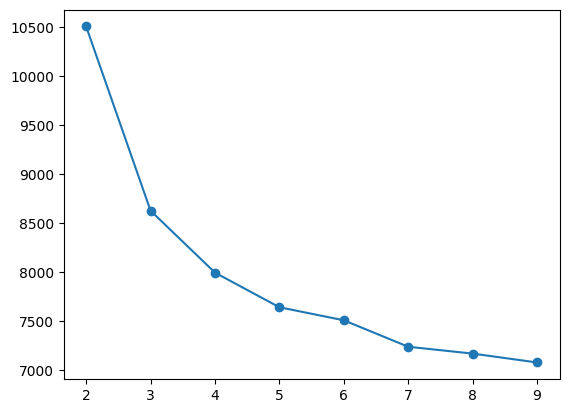

In [22]:
# 1. Reorder the dataframe: Numerical first, then Categorical
# (Excluding caseid_new as it shouldn't be a feature)
num_features = ['w1_relate_duration_in2017_years', 'w1_weekly_sex_frequency']
cat_features = ['w1_section', 'w1_ppage', 'w1_ppgender', 'w1_ppeducat', 'w1_partyid7', 
                'w1_ppmsacat', 'w1_same_sex_couple', 'w1_ppincimp_cat', 'w1_has_kids',
                'w1_meeting_type_refined', 'w1_max_relation_status', 'w1_q34', 'w1_q19', 'w1_married']

# Create a clean version with sorted columns
df_kproto = df_cluster[num_features + cat_features].copy()

# 2. Get the starting index of categorical columns
# Since we put numerical first, the index of the first categorical is len(num_features)
cat_idx = list(range(len(num_features), len(df_kproto.columns)))

# 3. Convert to values
data_matrix = df_kproto.values

# 4. Run Elbow Method
costs = []

for k in range(2, 10):
    print(f"Testing k={k}...")
    kproto = KPrototypes(n_clusters=k, init='Cao', n_init=1, verbose=0, random_state=42)
    kproto.fit(data_matrix, categorical=cat_idx)
    costs.append(kproto.cost_)

# Plot
import matplotlib.pyplot as plt
plt.plot(range(2, 10), costs, marker='o')
plt.show()


In [23]:
# 1. Run the final model with k=3
k_best = 3
kproto_final = KPrototypes(n_clusters=k_best, init='Cao', n_init=1, verbose=0, random_state=42)
clusters = kproto_final.fit_predict(data_matrix, categorical=cat_idx)

# 2. Add the cluster labels back to the original cleaned dataframe
df_cluster['relationship_cluster'] = clusters + 1  # +1 to make clusters start from 1 instead of 0

# 3. Quick check of the cluster sizes
print(df_cluster['relationship_cluster'].value_counts())


relationship_cluster
2    1351
1     970
3     436
Name: count, dtype: int64


In [24]:
df_cluster.info()

<class 'pandas.DataFrame'>
Index: 2757 entries, 0 to 3509
Data columns (total 18 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   caseid_new                       2757 non-null   int32  
 1   w1_section                       2757 non-null   str    
 2   w1_ppage                         2757 non-null   str    
 3   w1_ppgender                      2757 non-null   str    
 4   w1_ppeducat                      2757 non-null   str    
 5   w1_partyid7                      2757 non-null   str    
 6   w1_ppmsacat                      2757 non-null   str    
 7   w1_same_sex_couple               2757 non-null   str    
 8   w1_ppincimp_cat                  2757 non-null   str    
 9   w1_meeting_type_refined          2757 non-null   str    
 10  w1_max_relation_status           2757 non-null   str    
 11  w1_weekly_sex_frequency          2757 non-null   float32
 12  w1_q34                           275

In [25]:
df_cluster.head()

,caseid_new,w1_section,w1_ppage,w1_ppgender,w1_ppeducat,w1_partyid7,w1_ppmsacat,w1_same_sex_couple,w1_ppincimp_cat,w1_meeting_type_refined,w1_max_relation_status,w1_weekly_sex_frequency,w1_q34,w1_relate_duration_in2017_years,w1_q19,w1_married,w1_has_kids,relationship_cluster
0,53001,section 1: partnered adults,48,Female,High school,Not Strong Democrat,Non-Metro,NOT same-sex souple,$40K-$75K,Offline,married,0.025692,Excellent,-1.078318,Yes,yes,0,2
1,71609,section 1: partnered adults,68,Female,Some college,Leans Republican,Non-Metro,NOT same-sex souple,$40K-$75K,Offline,married,-0.679118,Excellent,1.878302,Yes,yes,0,1
2,106983,section 1: partnered adults,39,Male,Some college,Strong Democrat,Metro,NOT same-sex souple,$75K-$125K,Offline,married,0.025692,Excellent,-0.236433,Yes,yes,1,2
3,121759,section 1: partnered adults,54,Male,High school,Not Strong Republican,Metro,NOT same-sex souple,$75K-$125K,Offline,married,-0.467675,Excellent,0.354891,Yes,yes,0,2
5,164061,section 1: partnered adults,59,Male,Some college,Not Strong Republican,Metro,NOT same-sex souple,$75K-$125K,Offline,married,-0.679118,Excellent,0.124375,Yes,yes,0,2


In [26]:
print(df_cluster['w1_q34'].unique())


<StringArray>
['Excellent', 'Good', 'Fair', 'Very Poor', 'Poor']
Length: 5, dtype: str


In [27]:

# Transforming relationship quality to numeric scores for better interpretation
def get_cluster_profile(group):
    raw_group = df.loc[group.index]
    weights = raw_group['w1_weight_combo']
    
    profile = {}
    
    # 1. Duration of relationship (years) - weighted average
    profile['Years_Together'] = np.average(raw_group['w1_relate_duration_in2017_years'].fillna(0), weights=weights)
    
    # 2. Frequency of sex (number)
    valid_sex = raw_group['w1_weekly_sex_frequency'].notna()
    profile['Sex_Freq_Weekly'] = np.average(raw_group.loc[valid_sex, 'w1_weekly_sex_frequency'], weights=weights[valid_sex])
    
    # 3. Relationship quality (categorical) - convert to numeric scores and then average
    # Excellent=5, Good=4, Fair=3, Poor=2, Very Poor=1
    q_map = {'Excellent': 5, 'Good': 4, 'Fair': 3, 'Poor': 2, 'Very Poor': 1}
    q_scores = raw_group['w1_q34'].map(q_map).astype(float)
    profile['Happiness_Score'] = np.average(q_scores.dropna(), weights=weights[q_scores.notna()])
    
    # 4. Marriage rate (%)
    # This is a categorical column. We calculate the proportion of those who are 'yes' or '1'
    is_married = raw_group['w1_married'].astype(str).str.lower().str.contains('yes|1|married')
    profile['Marriage_Rate_%'] = np.average(is_married, weights=weights) * 100

    # 5. Kids rate (%)
    has_kids = raw_group['w1_has_kids'].astype(str).str.lower().str.contains('1|yes|true')
    profile['Has_Kids_%'] = np.average(has_kids, weights=weights) * 100

    # 6. NEW: Dating App Origin Rate (%) 
    # Calculates how many people in this cluster met via your new 'Dating App' category
    is_dating_app = raw_group['w1_meeting_type_refined'] == 'Dating App'
    profile['Dating_App_Origin_%'] = np.average(is_dating_app, weights=weights) * 100


    return pd.Series(profile)

interpretation_table = df_cluster.groupby('relationship_cluster').apply(get_cluster_profile)
print(interpretation_table.round(2))


                      Years_Together  Sex_Freq_Weekly  Happiness_Score  \
relationship_cluster                                                     
1                              40.25             0.65             4.59   
2                              11.32             0.87             4.35   
3                              11.57             5.18             4.58   

                      Marriage_Rate_%  Has_Kids_%  Dating_App_Origin_%  
relationship_cluster                                                    
1                               96.96       12.23                 0.00  
2                               63.37       44.41                10.43  
3                               58.06       45.50                 7.88  


In [28]:
# 1. Checking the number of clusters for k=5
kproto_5 = KPrototypes(n_clusters=5, init='Cao', n_init=1, verbose=0, random_state=42)
clusters_5 = kproto_5.fit_predict(data_matrix, categorical=cat_idx)

# 2. New labels for k=5
df_cluster['relationship_cluster_k5'] = clusters_5 + 1  # +1 to make clusters start from 1 instead of 0

# 3. New profiles for k=5 (using the same function as before)
interpretation_table_k5 = df_cluster.groupby('relationship_cluster_k5').apply(get_cluster_profile)

print("--- Profiles for K=3 ---")
print(interpretation_table.round(2))

print("\n--- Profiles for K=5 ---")
print(interpretation_table_k5.round(2))

# 4. Group sizes for k=5
print("\nGroup sizes for k=5:")
print(df_cluster['relationship_cluster_k5'].value_counts())


--- Profiles for K=3 ---
                      Years_Together  Sex_Freq_Weekly  Happiness_Score  \
relationship_cluster                                                     
1                              40.25             0.65             4.59   
2                              11.32             0.87             4.35   
3                              11.57             5.18             4.58   

                      Marriage_Rate_%  Has_Kids_%  Dating_App_Origin_%  
relationship_cluster                                                    
1                               96.96       12.23                 0.00  
2                               63.37       44.41                10.43  
3                               58.06       45.50                 7.88  

--- Profiles for K=5 ---
                         Years_Together  Sex_Freq_Weekly  Happiness_Score  \
relationship_cluster_k5                                                     
1                                 42.61             0.63   

--- WEIGHTED BREAKUP RATE PER CLUSTER (%) ---
relationship_cluster
1     1.13
2    59.12
3    24.38
4     5.71
5    13.51
dtype: float64




In [ ]:
#interpretation_table_k5 = 
#interpretation_table_k5["weighted_breakup_%"] = [1.13, 59.12, 24.38, 5.71, 13.51]
#interpretation_table_k5 = interpretation_table_k5.drop(columns="weighted_breakup")
interpretation_table_k5

,Years_Together,Sex_Freq_Weekly,Happiness_Score,Marriage_Rate_%,Has_Kids_%,Dating_App_Origin_%,weighted_breakup_%
relationship_cluster_k5,,,,,,,
1,42.613396,0.631195,4.624288,97.164729,6.503581,0.000000,1.13
2,4.781885,0.831839,4.096338,4.523161,32.018984,16.371465,59.12
3,11.565689,5.184730,4.578200,58.057234,45.499447,7.876831,24.38
4,14.586408,0.865401,4.520522,85.450887,18.274277,6.755461,5.71
5,17.451267,0.871517,4.384936,93.673656,76.201211,6.784114,13.51


<Axes: ylabel='relationship_cluster_k5'>

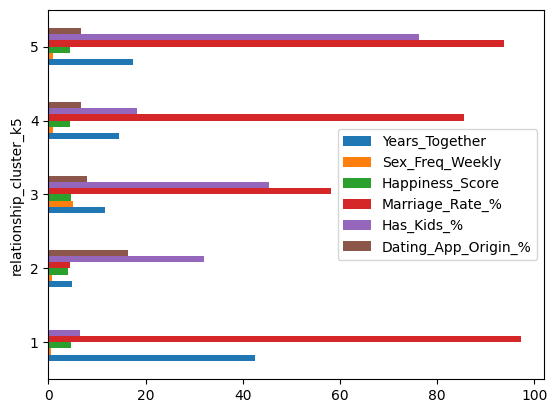

In [37]:
interpretation_table_k5.plot(kind='barh')


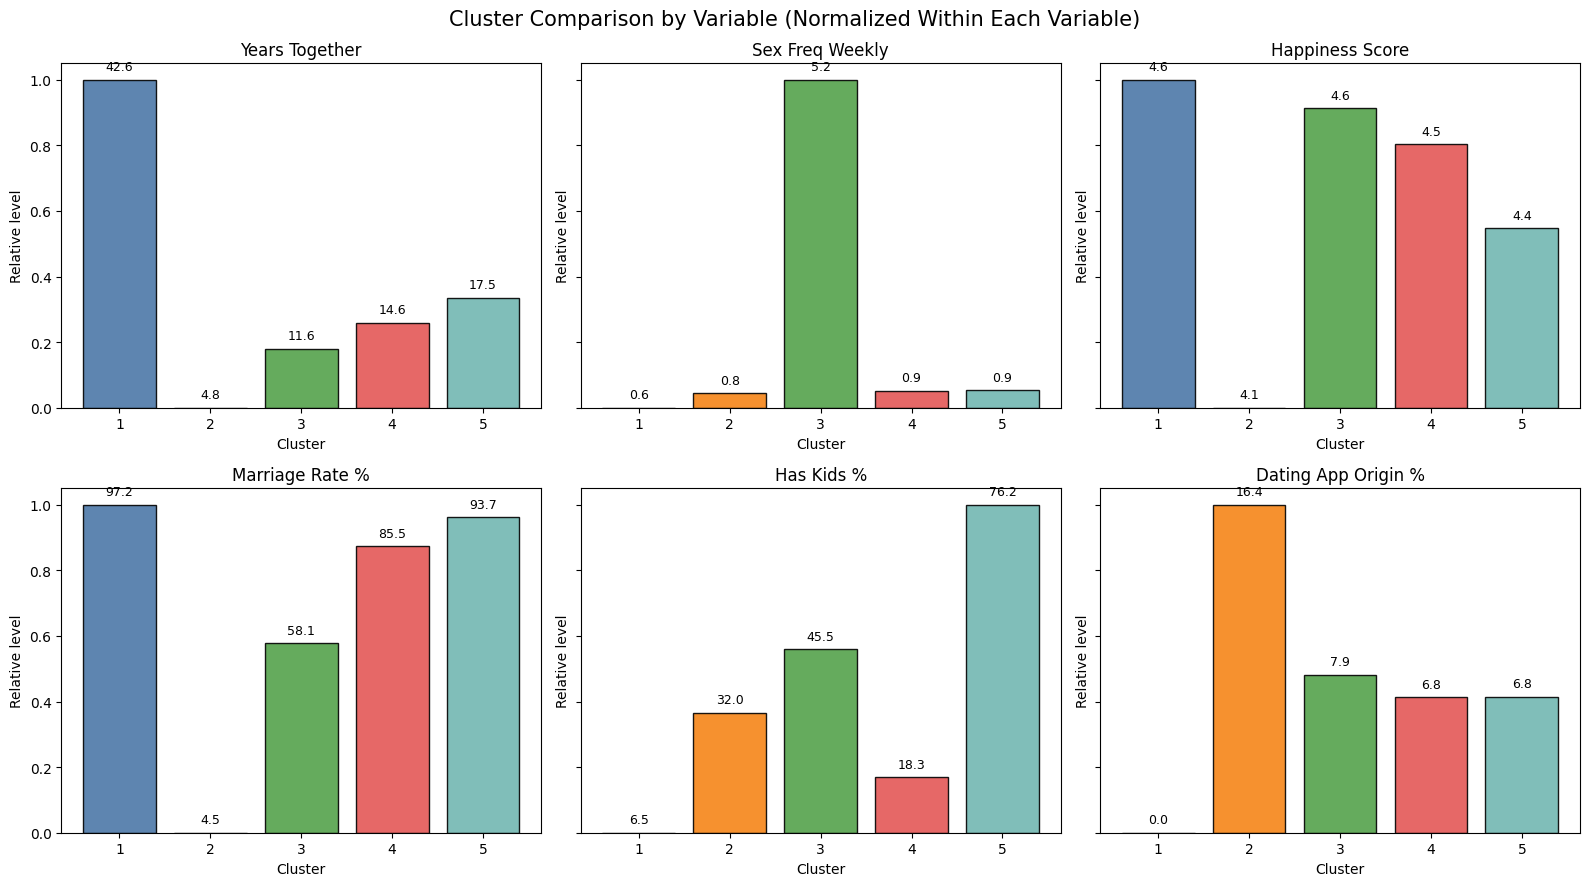

In [40]:
df_plot = interpretation_table_k5.copy()
# Normalize each column independently to [0, 1]
df_norm = (df_plot - df_plot.min()) / (df_plot.max() - df_plot.min())

# Colors for the clusters
colors = ['#4C78A8', '#F58518', '#54A24B', '#E45756', '#72B7B2']

fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=True)
axes = axes.flatten()

for i, col in enumerate(df_plot.columns):
    ax = axes[i]
    bars = ax.bar(
        df_plot.index.astype(str),
        df_norm[col],
        color=colors[:len(df_plot)],
        edgecolor='black',
        alpha=0.9
    )
    
    ax.set_title(col.replace('_', ' '), fontsize=12)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Relative level")
    
    # Show original values on top of bars
    for bar, raw_value in zip(bars, df_plot[col]):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.02,
            f"{raw_value:.1f}",
            ha='center',
            va='bottom',
            fontsize=9
        )

# Hide unused subplot if needed
if len(df_plot.columns) < len(axes):
    for j in range(len(df_plot.columns), len(axes)):
        axes[j].axis("off")

fig.suptitle("Cluster Comparison by Variable (Normalized Within Each Variable)", fontsize=15)
plt.tight_layout()
plt.show()

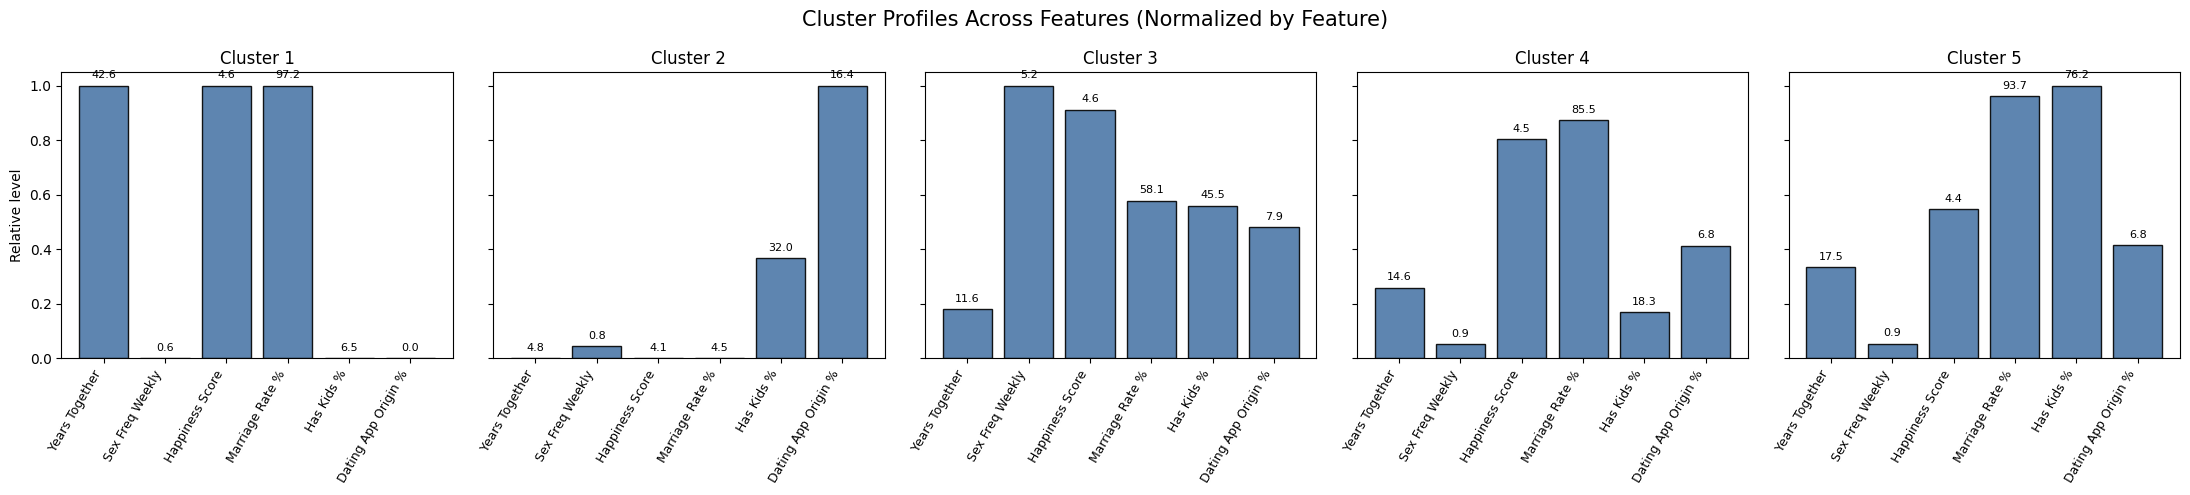

In [41]:
# Your cluster summary dataframe
df_plot = interpretation_table_k5.copy()

# Normalize each feature across clusters
df_norm = (df_plot - df_plot.min()) / (df_plot.max() - df_plot.min())

# Create 5 subplots: one for each cluster
fig, axes = plt.subplots(1, 5, figsize=(22, 5), sharey=True)
axes = axes.flatten()

for i, cluster in enumerate(df_plot.index):
    ax = axes[i]
    
    values = df_norm.loc[cluster]
    raw_values = df_plot.loc[cluster]
    
    bars = ax.bar(
        range(len(values)),
        values,
        color='#4C78A8',
        edgecolor='black',
        alpha=0.9
    )
    
    ax.set_title(f"Cluster {cluster}", fontsize=12)
    ax.set_ylim(0, 1.05)
    ax.set_xticks(range(len(values)))
    ax.set_xticklabels(
        [col.replace('_', ' ') for col in df_plot.columns],
        rotation=60,
        ha='right',
        fontsize=9
    )
    
    if i == 0:
        ax.set_ylabel("Relative level")
    
    # Show original values above bars
    for bar, raw_value in zip(bars, raw_values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f"{raw_value:.1f}",
            ha='center',
            va='bottom',
            fontsize=8
        )

fig.suptitle("Cluster Profiles Across Features (Normalized by Feature)", fontsize=15)
plt.tight_layout()
plt.show()

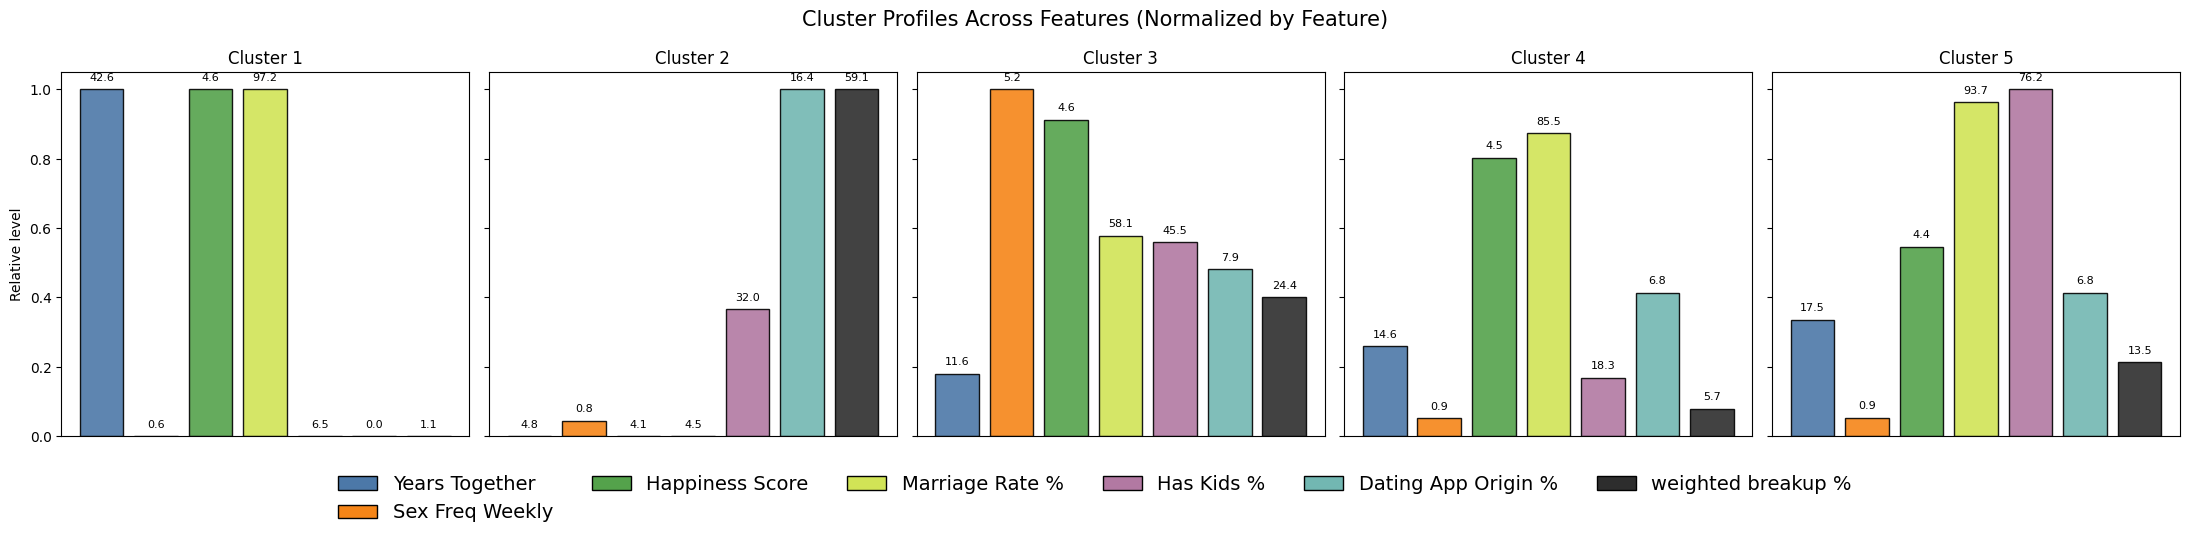

In [67]:
from matplotlib.patches import Patch

# Your cluster summary dataframe
df_plot = interpretation_table_k5.copy()

# Normalize each feature across clusters
df_norm = (df_plot - df_plot.min()) / (df_plot.max() - df_plot.min())

# Fixed color per feature
feature_colors = {
    "Years_Together": "#4C78A8",
    "Sex_Freq_Weekly": "#F58518",
    "Happiness_Score": "#54A24B",
    "Marriage_Rate_%": "#D1E456",
    "Has_Kids_%": "#B279A2",
    "Dating_App_Origin_%": "#72B7B2",
    "weighted_breakup_%":"#2D2D2D",
    
}

fig, axes = plt.subplots(1, 5, figsize=(22, 5), sharey=True)
axes = axes.flatten()

for i, cluster in enumerate(df_plot.index):
    ax = axes[i]

    values = df_norm.loc[cluster]
    raw_values = df_plot.loc[cluster]
    colors = [feature_colors[col] for col in df_plot.columns]

    bars = ax.bar(
        range(len(values)),
        values,
        color=colors,
        edgecolor='black',
        alpha=0.9
    )

    ax.set_title(f"Cluster {cluster}", fontsize=12)
    ax.set_ylim(0, 1.05)
    ax.set_xticks([])

    if i == 0:
        ax.set_ylabel("Relative level")

    # Original values on top
    for bar, raw_value in zip(bars, raw_values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f"{raw_value:.1f}",
            ha='center',
            va='bottom',
            fontsize=8
        )

# Shared legend
legend_handles = [
    Patch(facecolor=color, edgecolor='black', label=feature.replace('_', ' '))
    for feature, color in feature_colors.items()
]

fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=6,
    fontsize=14,
    frameon=False,
    bbox_to_anchor=(0.5, -0.08)
)

fig.suptitle("Cluster Profiles Across Features (Normalized by Feature)", fontsize=15)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

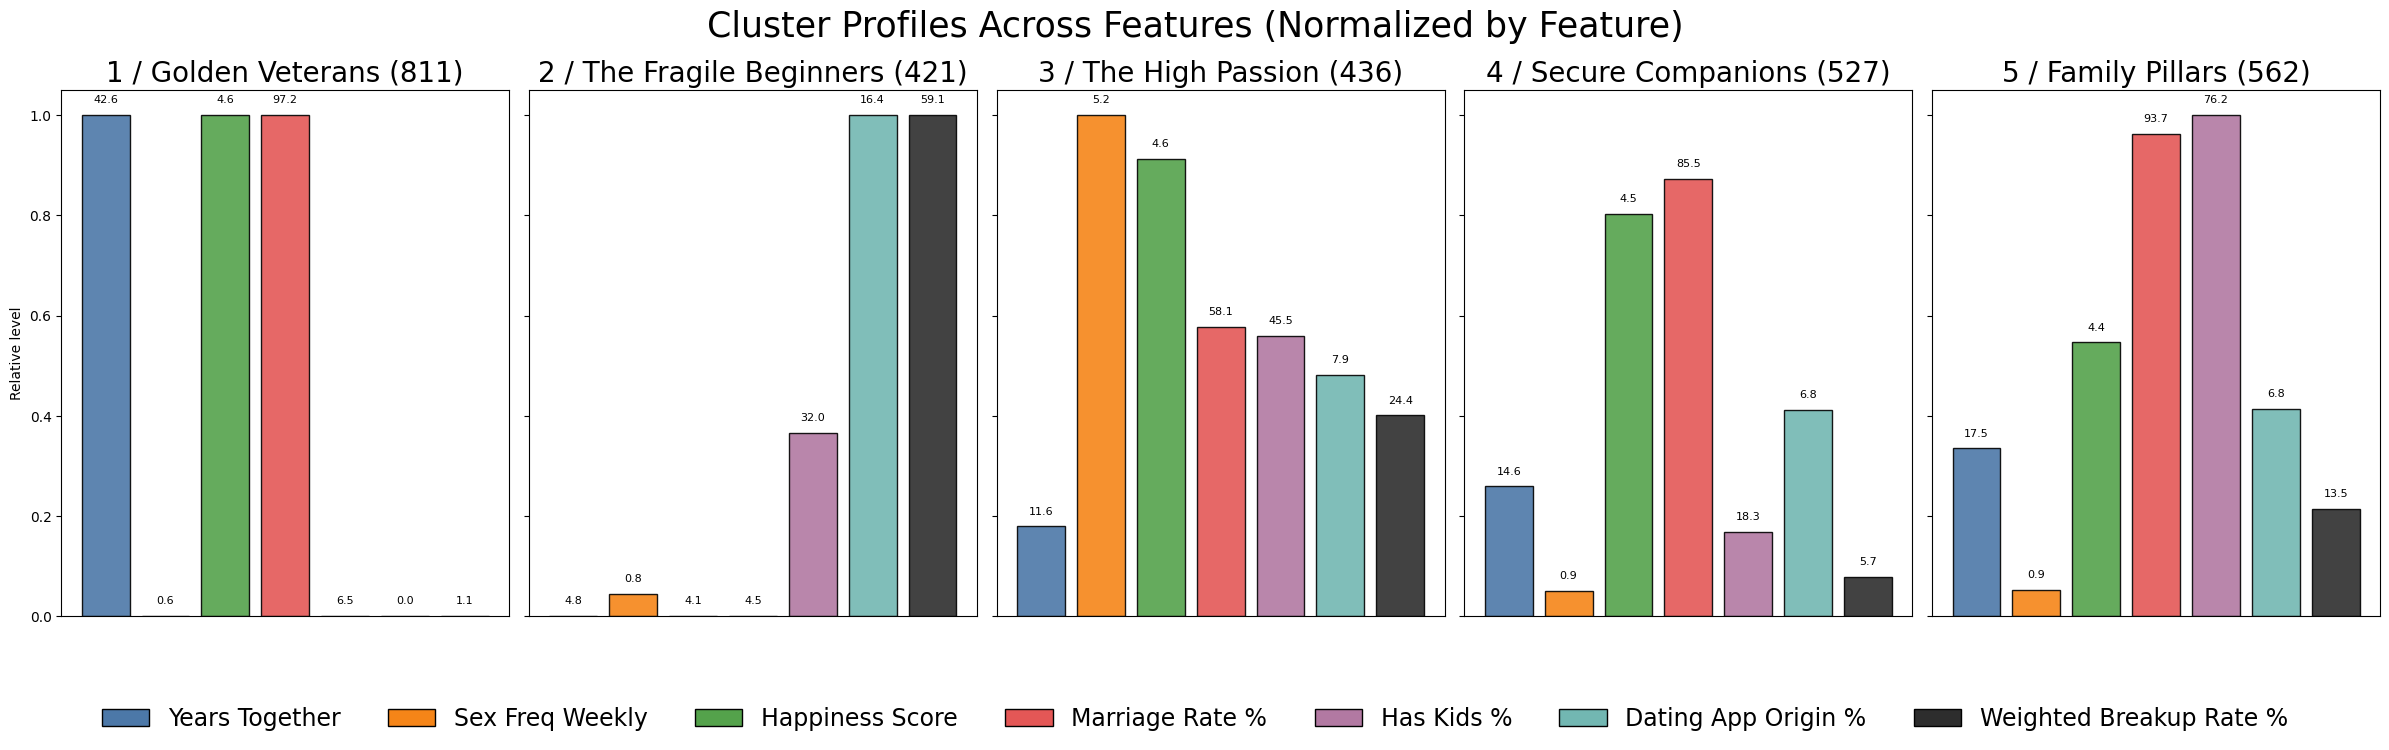

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Your cluster summary dataframe
df_plot = interpretation_table_k5.copy()

# Normalize each feature across clusters
df_norm = (df_plot - df_plot.min()) / (df_plot.max() - df_plot.min())

# Fixed color per feature
feature_colors = {
    "Years_Together": "#4C78A8",
    "Sex_Freq_Weekly": "#F58518",
    "Happiness_Score": "#54A24B",
    "Marriage_Rate_%": "#E45756",
    "Has_Kids_%": "#B279A2",
    "Dating_App_Origin_%": "#72B7B2",
    "weighted_breakup_%":"#2D2D2D",

}

# Custom subplot titles
cluster_titles = {
    1: "1 / Golden Veterans (811)",
    2: "2 / The Fragile Beginners (421)",
    3: "3 / The High Passion (436)",
    4: "4 / Secure Companions (527)",
    5: "5 / Family Pillars (562)",
}

# Cleaner legend labels
legend_labels = {
    "Years_Together": "Years Together",
    "Sex_Freq_Weekly": "Sex Freq Weekly",
    "Happiness_Score": "Happiness Score",
    "Marriage_Rate_%": "Marriage Rate %",
    "Has_Kids_%": "Has Kids %",
    "Dating_App_Origin_%": "Dating App Origin %",
    "weighted_breakup_%": "Weighted Breakup Rate %"
}

fig, axes = plt.subplots(1, 5, figsize=(24, 7), sharey=True)
axes = axes.flatten()

for i, cluster in enumerate(df_plot.index):
    ax = axes[i]

    values = df_norm.loc[cluster]
    raw_values = df_plot.loc[cluster]
    colors = [feature_colors[col] for col in df_plot.columns]

    bars = ax.bar(
        range(len(values)),
        values,
        color=colors,
        edgecolor='black',
        alpha=0.9
    )

    ax.set_title(cluster_titles[cluster], fontsize=20)
    ax.set_ylim(0, 1.05)
    ax.set_xticks([])

    if i == 0:
        ax.set_ylabel("Relative level")

    for bar, raw_value in zip(bars, raw_values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f"{raw_value:.1f}",
            ha='center',
            va='bottom',
            fontsize=8
        )

legend_handles = [
    Patch(facecolor=feature_colors[f], edgecolor='black', label=legend_labels[f])
    for f in df_plot.columns
]

fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=7,
    fontsize=17,
    frameon=False,
    bbox_to_anchor=(0.5, -0.08)
)

fig.suptitle("Cluster Profiles Across Features (Normalized by Feature)", fontsize=25)
plt.tight_layout(rect=[0, 0.08, 1, 1])
fig.savefig("clusters_bar.png", dpi=150, bbox_inches="tight")
plt.show()


# Stage 2 #

In [29]:
print(f"Unique values in w3_relationship_end_combo:")
for x in df['w3_relationship_end_combo'].unique():
    print(x)

print(f"\nUnique values in w2_relationship_end:")
for x in df['w2_relationship_end'].unique():
    print(x)

Unique values in w3_relationship_end_combo:
no report of breakup or partner death
nan
Separated/ Broke up
Partner died
Got Divorced

Unique values in w2_relationship_end:
Divorce
no report of breakup or partner death
nan
Partner died
Separation or other breakup


In [30]:
def identify_breakup(row):
    # Lists of strings that indicate a breakup based on your output
    breakup_labels = [
        'Separated/ Broke up', 
        'Got Divorced', 
        'Divorce', 
        'Separation or other breakup'
    ]
    
    # 1. Check for Breakups
    if (row['w2_relationship_end'] in breakup_labels) or \
       (row['w3_relationship_end_combo'] in breakup_labels):
        return 1
    
    # 2. Check for Death (Exclude these from the model)
    if (row['w2_relationship_end'] == 'Partner died') or \
       (row['w3_relationship_end_combo'] == 'Partner died'):
        return np.nan
    
    # 3. Check for "Still Together"
    # Only if they actually provided a report in Wave 3
    if row['w3_relationship_end_combo'] == 'no report of breakup or partner death':
        return 0
        
    return np.nan

# Apply to the main dataframe
df['target_breakup'] = df.apply(identify_breakup, axis=1)

# Add K=5 cluster labels to the main dataframe
df['relationship_cluster'] = df_cluster['relationship_cluster_k5']

# Final Check
print("Distribution of Relationship Outcomes (2017-2022):")
print(df['target_breakup'].value_counts())


Distribution of Relationship Outcomes (2017-2022):
target_breakup
0.0    1480
1.0     237
Name: count, dtype: int64


In [31]:
# 1. Corrected feature list including the Meeting Method
features_for_model = [
    'relationship_cluster',           # From Part 1
    'w1_meeting_type_refined',        # WHERE they met (Online/Offline) - ADDED HERE
    'w1_ppage',                       # Age
    'w1_relate_duration_in2017_years',# Stability
    'w1_q34',                         # Initial Quality
    'w1_married',                     # Marital status
    'w1_ppeducat',                    # Education
    'w1_has_kids'                     # Kids status
]

# 2. Preparation of the dataset
# We keep weights to ensure the model learns from a representative sample
df_model = df[features_for_model + ['target_breakup', 'w3_attrition_adj_weight']].copy()

# Drop rows where we don't have a known target (2022 outcome)
df_model = df_model.dropna(subset=['target_breakup'])

# 3. Define which features are Categorical for CatBoost
# CatBoost is great because it handles these without "One-Hot Encoding"
cat_features = [
    'relationship_cluster', 
    'w1_meeting_type_refined', 
    'w1_q34', 
    'w1_married', 
    'w1_ppeducat',
    'w1_has_kids'
]


In [32]:
def get_breakup_rate(group):
    # Filter to ensure we only use rows where BOTH target and weight are present
    valid_data = group.dropna(subset=['target_breakup', 'w3_attrition_adj_weight'])
    
    if len(valid_data) == 0:
        return np.nan
    
    # Weighted average of 1s and 0s
    return np.average(valid_data['target_breakup'], weights=valid_data['w3_attrition_adj_weight']) * 100

breakup_report = df_model.groupby('relationship_cluster').apply(get_breakup_rate)
breakup_report.index = breakup_report.index.astype(int)

print("--- WEIGHTED BREAKUP RATE PER CLUSTER (%) ---")
print(breakup_report.round(2))


--- WEIGHTED BREAKUP RATE PER CLUSTER (%) ---
relationship_cluster
1     1.13
2    59.12
3    24.38
4     5.71
5    13.51
dtype: float64


In [33]:

# 1. Clean the data - drop rows with missing target or weights
df_final = df_model.dropna(subset=['target_breakup', 'w3_attrition_adj_weight']).copy()

# 2. Define features
feature_cols = [
    'relationship_cluster', 
    'w1_meeting_type_refined', 
    'w1_ppage', 
    'w1_relate_duration_in2017_years', 
    'w1_q34', 
    'w1_married', 
    'w1_ppeducat',
    'w1_has_kids'
]

# 3. CRITICAL FIX: Force all Categorical features to be strings using list comprehension
# This effectively kills all Pandas Categorical/NaN objects
cat_features = ['relationship_cluster', 'w1_meeting_type_refined', 'w1_ppage', 'w1_q34', 'w1_married', 'w1_ppeducat', 'w1_has_kids']

for col in cat_features:
    # Convert every value to string individually and handle hidden 'nan'
    df_final[col] = [str(val) if (val is not None and str(val) != 'nan') else "Unknown" for val in df_final[col]]

# 4. Prepare X, y and Weights
X = df_final[feature_cols]
y = df_final['target_breakup'].astype(int)
weights = df_final['w3_attrition_adj_weight']

# Identify categorical indices
cat_indices = [X.columns.get_loc(col) for col in cat_features]

# 5. Train/Test Split
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, weights, test_size=0.2, random_state=42
)

# 6. Final Model Fit
model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    cat_features=cat_indices,
    verbose=100
)

model.fit(X_train, y_train, sample_weight=w_train, eval_set=(X_test, y_test))

# 7. Print Importance
feat_imp = pd.DataFrame({'feature': X.columns, 'importance': model.get_feature_importance()})
print(feat_imp.sort_values(by='importance', ascending=False))


NameError: name 'CatBoostClassifier' is not defined

In [ ]:
# 1. Pull importance directly from my trained CatBoost model
# This ensures that if you re-run the model, the chart updates automatically
feat_imp_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.get_feature_importance()
})

# Sort the values for a clean horizontal bar chart
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

# 2. Setup the visual style
plt.figure(figsize=(10, 7))
sns.set_theme(style="whitegrid")

# 3. Build the plot
# Fixed: Assigning 'Feature' to 'hue' and setting legend=False to remove the warning
plot = sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feat_imp_df, 
    hue='Feature',
    palette='viridis',
    legend=False
)

# 4. Add data labels (the actual % numbers) on the bars
for i in plot.containers:
    plot.bar_label(i, fmt='%.2f%%', padding=5)

# 5. Formatting
plt.title('What Actually Predicts a Breakup? (CatBoost Importance)', fontsize=15, pad=20, fontweight='bold')
plt.xlabel('Importance Score (%)', fontsize=12)
plt.ylabel('') # Clean up the Y axis label
plt.xlim(0, feat_imp_df['Importance'].max() + 5) # Dynamically set X-limit

plt.tight_layout()

# 6. Save for your presentation
plt.savefig('okcupid_feature_importance_dynamic.png', dpi=300)
plt.show()


In [ ]:
# Saving models


# 1. Save the Scaler
with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# 2. Save the K-Prototypes Model
with open('../models/kproto_model.pkl', 'wb') as f:
    pickle.dump(kproto_5, f)

# 3. Save the CatBoost Model
model.save_model('../models/catboost_relationship_model.cbm')

print("Success! All 3 files are now in your project folder.")


In [ ]:
# PREDICTING WITH NEW DATA
def prepare_new_data(df_input):
    # User experience
    raw_input = {
        'caseid_new', # Need to create this unique ID in the raw data before feeding it to the model
        'w1_section',
        'w1_ppage',
        'w1_ppgender',
        'w1_ppeducat',
        'w1_partyid7',
        'w1_ppmsacat',
        'w1_same_sex_couple',
        'w1_ppincimp_cat',
        'w1_q32', # needs to be refined into 'w1_meeting_type_refined'
        'w1_meeting_type_refined',
        'w1_max_relation_status',
        'w1_weekly_sex_frequency',
        'w1_q34',
        'w1_relate_duration_in2017_years',
        'w1_q19',
        'w1_married',
        'w1_PPT01', # This is the raw feature for kids, which needs to be transformed into 'w1_has_kids' before feeding to the model
        'w1_PPT25', # This is the raw feature for kids, which needs to be transformed into 'w1_has_kids' before feeding to the model
        'w1_PPT612', # This is the raw feature for kids, which needs to be transformed into 'w1_has_kids' before feeding to the model
        'w1_PPT1317', # This is the raw feature for kids, which needs to be transformed into 'w1_has_kids' before feeding to the model
    }

    df_input = pd.DataFrame([raw_input])

    # Transform the raw input into the features needed for the cluster assignment and prediction, including:
    # - Create 'caseid_new' if needed
    df_input['caseid_new'] = 111111111111111

    # - Create 'w1_has_kids' from the raw PPT columns
    df_input['w1_has_kids'] = (df_input[['w1_PPT01', 'w1_PPT25', 'w1_PPT612', 'w1_PPT1317']].sum(axis=1) > 0).astype(int)

    # - Refine 'w1_q32' into 'w1_meeting_type_refined'
    df_input['w1_meeting_type_refined'] = df_input['w1_q32'].apply(consolidate_meeting_method)

    # Scale the numerical features using the saved scaler
    num_features = ['w1_relate_duration_in2017_years', 'w1_weekly_sex_frequency']
    df_input[num_features] = scaler.transform(df_input[num_features])

    # Transform categorical features to string
    cat_features = ['w1_section', 'w1_ppgender', 'w1_ppeducat', 'w1_partyid7', 'w1_ppgender',
                    'w1_ppmsacat', 'w1_same_sex_couple', 'w1_ppincimp_cat', 'w1_ppage',
                    'w1_meeting_type_refined', 'w1_max_relation_status', 'w1_q34', 'w1_q19', 'w1_married', 'w1_has_kids']

    for col in cat_features:
        df_input[col] = df_input[col].astype(str)

    return df_input


